In [1]:
import networkx as nx
import os
import pandas as pd
import random
from itertools import product

In [2]:
users = [x[:-4] for x in os.listdir('./profiles/')]

In [3]:
users

['chloe.roberts',
 'daniel.evans',
 'aria.green',
 'william.wright',
 'jackson.reed',
 'ethan.king',
 'benjamin.walker',
 'charlotte.white',
 'elijah.jackson',
 'noah.wilson',
 'alexander.adams',
 'harper.hill',
 'ava.taylor',
 'olivia.brown',
 'amelia.clark',
 'mia.anderson',
 'mason.harris',
 'isabella.moore',
 'abigail.phillips',
 'liam.jones',
 'michael.baker',
 'lucas.thomas',
 'emma.smith',
 'ella.nelson',
 'grace.ward',
 'evelyn.scott',
 'logan.lewis',
 'henry.carter',
 'sophia.hall',
 'james.martin']

In [4]:
df = pd.DataFrame(columns=['id','gender','username','name','image_name','image_uuid'])

In [5]:
df['id'] = random.sample(range(100000, 1000000), len(users))

In [6]:
df['gender'] = [
    'F',
    'M',
    'F',
    'M',
    'M',
    'M',
    'M',
    'F',
    'M',
    'M',
    'M',
    'F',
    'F',
    'F',
    'F',
    'F',
    'M',
    'F',
    'F',
    'M',
    'M',
    'M',
    'F',
    'F',
    'F',
    'F',
    'M',
    'M',
    'F',
    'M',

]

In [7]:
df['username'] = users
df['name'] = users

In [8]:
df['image_name'] = [x + '.jpg' for x in users]

In [9]:
df

,id,gender,username,name,image_name,image_uuid
0,954088,F,chloe.roberts,chloe.roberts,chloe.roberts.jpg,NaN
1,205965,M,daniel.evans,daniel.evans,daniel.evans.jpg,NaN
2,444474,F,aria.green,aria.green,aria.green.jpg,NaN
3,807855,M,william.wright,william.wright,william.wright.jpg,NaN
4,699108,M,jackson.reed,jackson.reed,jackson.reed.jpg,NaN
5,847269,M,ethan.king,ethan.king,ethan.king.jpg,NaN
6,451728,M,benjamin.walker,benjamin.walker,benjamin.walker.jpg,NaN
7,827652,F,charlotte.white,charlotte.white,charlotte.white.jpg,NaN
8,157856,M,elijah.jackson,elijah.jackson,elijah.jackson.jpg,NaN
9,643420,M,noah.wilson,noah.wilson,noah.wilson.jpg,NaN


In [10]:
a = random.sample(range(10, 100), len(users))
b = random.sample(range(1000, 10000), len(users))
c = random.sample(range(100000, 1000000), len(users))

In [11]:
df['image_uuid'] = [f'{x}-{y}-{z}' for x, y, z in zip(a, b, c)]

In [12]:
df

,id,gender,username,name,image_name,image_uuid
0,954088,F,chloe.roberts,chloe.roberts,chloe.roberts.jpg,84-8462-658939
1,205965,M,daniel.evans,daniel.evans,daniel.evans.jpg,46-8621-824500
2,444474,F,aria.green,aria.green,aria.green.jpg,57-2721-149942
3,807855,M,william.wright,william.wright,william.wright.jpg,53-9370-223288
4,699108,M,jackson.reed,jackson.reed,jackson.reed.jpg,65-4036-269529
5,847269,M,ethan.king,ethan.king,ethan.king.jpg,77-8577-437308
6,451728,M,benjamin.walker,benjamin.walker,benjamin.walker.jpg,67-8850-931861
7,827652,F,charlotte.white,charlotte.white,charlotte.white.jpg,42-8234-151801
8,157856,M,elijah.jackson,elijah.jackson,elijah.jackson.jpg,13-3155-922174
9,643420,M,noah.wilson,noah.wilson,noah.wilson.jpg,27-9968-123839


In [13]:
df = df.set_index('id')

In [14]:
G = nx.Graph()
G.add_nodes_from(df['name'])

In [15]:
for x, y in product(G.nodes(), G.nodes()):
    if x != y:
        G.add_edge(x, y, relationship='positive')

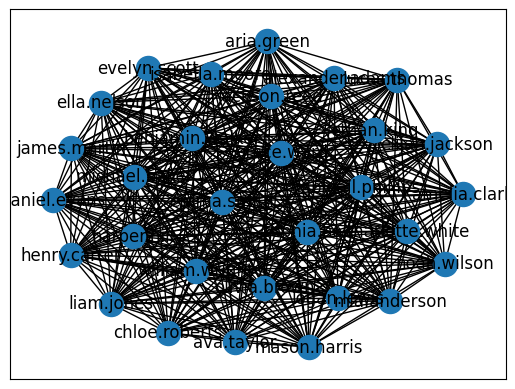

In [16]:
nx.draw_networkx(G)

In [17]:
neutral_edges = random.sample(list(G.edges()), 200)
G.remove_edges_from(neutral_edges)
G.add_edges_from(neutral_edges, relationship='neutral')

In [18]:
negative_edges = random.sample(list(G.edges()), 100)
G.remove_edges_from(negative_edges)
G.add_edges_from(negative_edges, relationship='negative')

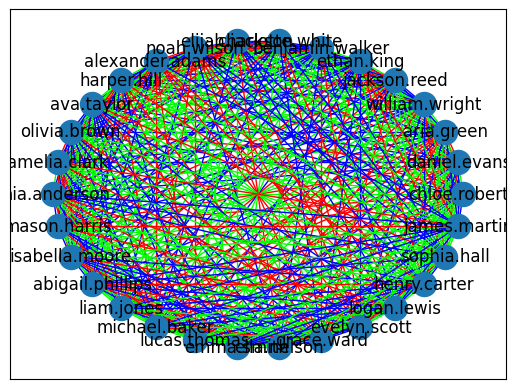

In [29]:
nx.draw_networkx(G, pos=nx.circular_layout(G), edge_color = ['#00ff00' if x[2]['relationship'] == 'positive' else '#0000ff' if x[2]['relationship'] == 'neutral' else '#ff0000' for x in G.edges(data=True)])

In [46]:
[x[1] for x in G.edges(data=True) if x[0] == 'alexander.adams' and x[2]['relationship'] == 'positive']

['harper.hill',
 'amelia.clark',
 'liam.jones',
 'emma.smith',
 'ella.nelson',
 'grace.ward',
 'sophia.hall']

In [49]:
df['positive'] = df['username'].apply(lambda user : [x[1] for x in G.edges(data=True) if x[0] == user and x[2]['relationship'] == 'positive'])
df['neutral'] = df['username'].apply(lambda user : [x[1] for x in G.edges(data=True) if x[0] == user and x[2]['relationship'] == 'neutral'])
df['negative'] = df['username'].apply(lambda user : [x[1] for x in G.edges(data=True) if x[0] == user and x[2]['relationship'] == 'negative'])

In [51]:
df.to_csv('./profile.csv')

In [52]:
df

,gender,username,name,image_name,image_uuid,positive,neutral,negative
id,,,,,,,,
954088,F,chloe.roberts,chloe.roberts,chloe.roberts.jpg,84-8462-658939,"[daniel.evans, jackson.reed, charlotte.white, ...","[emma.smith, noah.wilson, benjamin.walker, gra...","[elijah.jackson, aria.green, harper.hill, isab..."
205965,M,daniel.evans,daniel.evans,daniel.evans.jpg,46-8621-824500,"[william.wright, jackson.reed, elijah.jackson,...","[ava.taylor, amelia.clark, ethan.king, mia.and...","[grace.ward, mason.harris, olivia.brown, noah...."
444474,F,aria.green,aria.green,aria.green.jpg,57-2721-149942,"[william.wright, ethan.king, benjamin.walker, ...","[noah.wilson, elijah.jackson, logan.lewis, abi...","[liam.jones, michael.baker, ella.nelson, charl..."
807855,M,william.wright,william.wright,william.wright.jpg,53-9370-223288,"[charlotte.white, alexander.adams, ava.taylor,...","[mia.anderson, mason.harris, ethan.king, jacks...","[sophia.hall, emma.smith, michael.baker, noah...."
699108,M,jackson.reed,jackson.reed,jackson.reed.jpg,65-4036-269529,"[ethan.king, alexander.adams, amelia.clark, mi...","[emma.smith, harper.hill, noah.wilson, michael...","[lucas.thomas, elijah.jackson, mason.harris, b..."
847269,M,ethan.king,ethan.king,ethan.king.jpg,77-8577-437308,"[benjamin.walker, noah.wilson, alexander.adams...","[michael.baker, grace.ward, lucas.thomas, evel...","[james.martin, sophia.hall, ella.nelson, henry..."
451728,M,benjamin.walker,benjamin.walker,benjamin.walker.jpg,67-8850-931861,"[ava.taylor, amelia.clark, abigail.phillips, m...","[mason.harris, olivia.brown, alexander.adams, ...","[evelyn.scott, grace.ward, harper.hill]"
827652,F,charlotte.white,charlotte.white,charlotte.white.jpg,42-8234-151801,"[alexander.adams, olivia.brown, mia.anderson, ...","[amelia.clark, grace.ward, isabella.moore, eli...","[evelyn.scott, noah.wilson, harper.hill, logan..."
157856,M,elijah.jackson,elijah.jackson,elijah.jackson.jpg,13-3155-922174,"[harper.hill, ava.taylor, mason.harris, isabel...","[sophia.hall, henry.carter, logan.lewis, micha...","[alexander.adams, evelyn.scott, mia.anderson, ..."
